<a href="https://colab.research.google.com/github/himanshusar123/-Machine-Learning-Quiz-Classification-or-Regression-/blob/main/XG_boost.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
!pip install xgboost

In [2]:
import pandas as pd

from sklearn.model_selection import train_test_split

from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report
)

from xgboost import XGBClassifier

In [3]:
from google.colab import files
uploaded = files.upload()

Saving Employee_Promotion_Prediction (1).csv to Employee_Promotion_Prediction (1).csv


In [7]:
df = pd.read_csv(
    "Employee_Promotion_Prediction (1).csv"
)

In [8]:
df["Promotion"] = df["Promotion"].map({
    "No":0,
    "Yes":1
})

In [9]:
X = df[
    [
        "Age",
        "Experience_Years",
        "Performance_Rating",
        "Training_Hours",
        "Projects_Completed",
        "Attendance_Percentage"
    ]
]

In [10]:
y = df["Promotion"]

In [11]:
X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

In [12]:
model = XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

In [13]:
model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric=None, feature_types=None,
              feature_weights=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=0.1, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=100,
              n_jobs=None, num_parallel_tree=None, ...)

In [14]:
y_pred = model.predict(
    X_test
)

In [15]:
accuracy = accuracy_score(
    y_test,
    y_pred
)

print(
    "Accuracy:",
    accuracy
)

Accuracy: 0.962


In [16]:
cm = confusion_matrix(
    y_test,
    y_pred
)

print(cm)

[[257  11]
 [  8 224]]


In [17]:
print(
    classification_report(
        y_test,
        y_pred
    )
)

              precision    recall  f1-score   support

           0       0.97      0.96      0.96       268
           1       0.95      0.97      0.96       232

    accuracy                           0.96       500
   macro avg       0.96      0.96      0.96       500
weighted avg       0.96      0.96      0.96       500



In [18]:
importance = pd.DataFrame({
    "Feature":X.columns,
    "Importance":model.feature_importances_
})

importance.sort_values(
    by="Importance",
    ascending=False
)

,Feature,Importance
4,Projects_Completed,0.380586
2,Performance_Rating,0.235215
1,Experience_Years,0.201450
3,Training_Hours,0.095580
0,Age,0.051176
5,Attendance_Percentage,0.035992


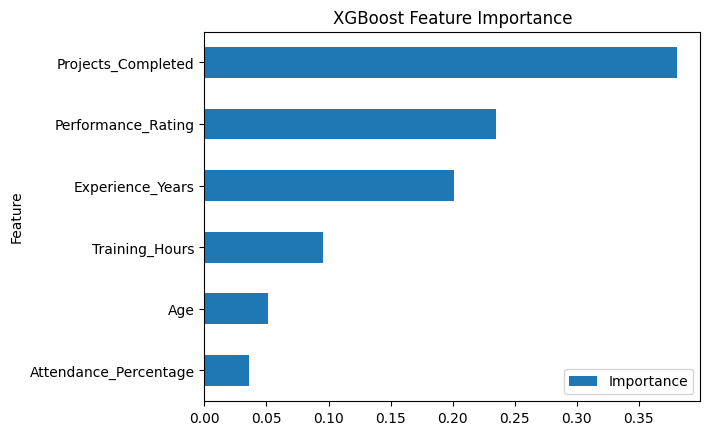

In [19]:
import matplotlib.pyplot as plt

importance.sort_values(
    by="Importance"
).plot(
    x="Feature",
    y="Importance",
    kind="barh"
)

plt.title(
    "XGBoost Feature Importance"
)

plt.show()